# Too complicated to Model

This notebook is part of my **PyCon ZA 2026** and **Swiss Python Summit 2026** talks, *Missing Female Data*.

The data used here have already been cleaned and prepared in a separate data-preparation notebook. I am working with my **running activities** and the variables needed for the modelling exercise, including pace and `cycle_position`.

`cycle_position` describes where an activity falls within my 28-day oral-contraceptive schedule. It should not be interpreted as a verified biological menstrual-cycle phase or as equivalent to a natural menstrual cycle.

For this part of the talk, I want to take the same underlying data and try three different ways of representing cycle position in a model:

1. **Phase categories** — dividing cycle position into predefined groups.
2. **Cyclical terms** — representing where an observation falls within the cycle as a continuous, repeating variable.
3. **A cyclic GAM** — allowing the relationship to take a more flexible shape.

I don't expect this little dataset to tell us anything about women in general. It is one person's training history, with all the messiness that comes with real-world data.

What I want to see is much simpler:

**What does each model actually do with the cycle information?**

Does treating cycle position as a few categories tell us something different from treating it as a continuous, cyclical variable? And what happens when we give the model more freedom to describe the relationship?

So this is less about finding *the* right model, and more about seeing how our modelling assumptions change what the model can see.


## Modelling the cycle

**BASELINE**

```text
Y = Xβ + ε
```

↓

**CYCLE AS A PREDICTOR**

```text
Y = Xβ + f(cycle day) + ε
```

There are already studies where menstrual-cycle information is included as a variable in the analysis, rather than being treated as something that makes the data too complicated.

So let's look at some of the ways we can actually represent the cycle.

### 01 — PHASE CATEGORIES

```text
C(phase)
```

Phase categories are useful because they are simple and easy to interpret.

For example, it is very straightforward to say:

> “Performance differed between the luteal and follicular phases.”

The model might see the cycle something like this:

| Cycle day | Model sees |
|---|---|
| 1–5 | Menstrual |
| 6–13 | Follicular |
| 14 | Ovulation |
| 15–28 | Luteal |

But there is a trade-off.

When we turn the cycle into categories, we are deciding in advance where the boundaries are:

```text
Days 1–5       = one thing
Days 6–13      = another thing
Day 14         = another thing
Days 15–28     = another thing
```

The model no longer sees the difference between, for example, day 6 and day 13. It just sees **follicular phase**.

There is also a biological problem with assuming that everyone follows exactly the same timeline. Cycle length varies, and the timing of biological events can vary too. So “day 14 = ovulation” is not a universal rule.

We have taken something continuous, individual and cyclical, and turned it into a few predefined boxes.

### A real example

For this first model, I’m using *Impact of the Menstrual Cycle Phases on the Movement Patterns of Sub-Elite Women Soccer Players during Competitive Matches* as a methodological example.

The researchers divided the cycle into three phases:

- **EF** — early follicular
- **LF** — late follicular
- **ML** — mid-luteal

They then asked a fairly simple question:

> **Does performance differ between these phases?**

Their analysis used a linear mixed-effects model including menstrual phase, game period, the interaction between the two, and player as a random effect:

```text
performance ~ menstrual_phase
            + game_period
            + menstrual_phase × game_period
            + player
```

This is a useful starting point for my own data because it gives me a concrete example of what happens when **cycle phase becomes a model variable**.

Now I want to try the same basic idea with my Garmin data and then I want to remove the boxes.

#### Import the Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Read and prepare the data

In [22]:
# we are only going to focus on running
df= pd.read_csv("running.csv")
df.head()

,activity_type,date,title,cycle_position,distance,calories,time,avg_HR,max_HR,aerobic _TE,...,min_temp,decompression,best_lap_time,number_of_laps,max_temp,moving_time,elapsed_time,min_elevation,max_elevation,datetime
0,Running,2026-09-26,Berlin - Breakfast Run,12,4.52,306,10:01:38,175,191,4.3,...,NaN,No,0:03:40,5,NaN,0:29:12,0:32:33,33,40,2026-09-26 10:01:38
1,Running,2026-09-20,Berlin - Rehberge Viertelmarathon,6,10.24,644,11:01:24,176,202,5.0,...,NaN,No,0:00:45,12,NaN,1:14:23,1:14:25,31,52,2026-09-20 11:01:24
2,Running,2026-09-15,Berlin - Base,1,7.28,483,18:45:31,174,191,5.0,...,NaN,No,0:00:01,9,NaN,0:49:44,0:51:49,32,37,2026-09-15 18:45:31
3,Running,2026-09-08,Berlin - Base,23,7.10,469,18:44:12,170,188,4.4,...,NaN,No,0:03:07,8,NaN,0:48:01,0:52:02,28,35,2026-09-08 18:44:12
4,Running,2026-08-29,Vollmond Halbmarathon,13,21.17,"1,374",17:00:02,168,187,5.0,...,NaN,No,0:03:33,22,NaN,2:52:18,2:56:38,25,35,2026-08-29 17:00:02


In [23]:
df.dtypes

activity_type                   str
date                            str
title                           str
cycle_position                int64
distance                    float64
calories                        str
time                            str
avg_HR                        int64
max_HR                        int64
aerobic _TE                 float64
avg_run_cadence               int64
max_run_cadence               int64
avg_pace                        str
best_pace                       str
total_ascent                  int64
total_descent                 int64
avg_stride_length           float64
avg_vertical_ratio          float64
avg_vertical_Oscillation    float64
avg_ground_contact_time       int64
avg_GAP                         str
normalized_power              int64
training_stress_score         int64
avg_power                     int64
max_power                       str
total_strokes               float64
avg_swolf                   float64
avg_stroke_rate             

In [24]:
# we want to change the data type of pace
def pace_to_seconds(pace):
    minutes, seconds = pace.split(":")
    return int(minutes) * 60 + int(seconds)

df["pace_seconds"] = df["avg_pace"].apply(pace_to_seconds)

In [25]:
df[["cycle_position", "avg_pace", "pace_seconds"]].head(10)

,cycle_position,avg_pace,pace_seconds
0,12,7:12,432
1,6,7:16,436
2,1,7:07,427
3,23,7:20,440
4,13,8:20,500
5,9,6:47,407
6,2,7:23,443
7,27,7:22,442
8,22,7:43,463
9,17,8:02,482


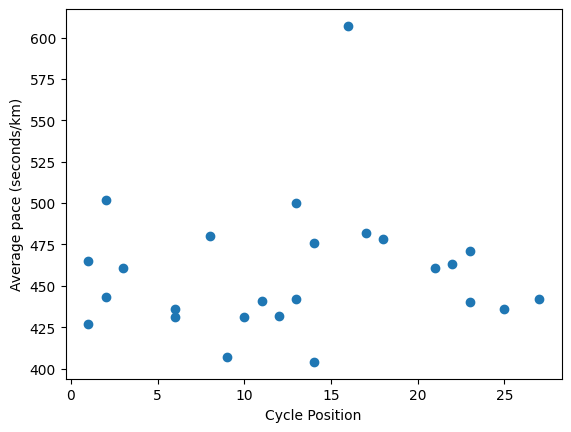

In [26]:
plt.scatter(df["cycle_position"], df["pace_seconds"])
plt.xlabel("Cycle Position")
plt.ylabel("Average pace (seconds/km)")
plt.show()

In [27]:
df["pace_seconds"].mean()

458.32

If we know nothing about cycle position, our model predicts 458.32 seconds/km for every run.

## 1. Start with a baseline

Before adding cycle position, I want a simple reference point. So let's start with the simplest version: **what happens if I don't give the model any information about cycle position?**

The baseline model predicts the same pace for every run: the overall average pace.

In `statsmodels`:

```text
pace_seconds ~ 1
```

Here, `1` means the model contains only an intercept, no predictors.

So this model is simply:

```text
predicted pace = average pace
```

It's deliberately simple. I need this reference point before asking what changes when cycle position is added.

```python
import statsmodels.formula.api as smf

baseline = smf.ols(
    "pace_seconds ~ 1",
    data=df
).fit()
```



In [34]:
import statsmodels.formula.api as smf

baseline = smf.ols(
    "pace_seconds ~ 1",
    data=df
).fit()

In [35]:
baseline.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           pace_seconds   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 30 Sep 2026   Prob (F-statistic):                nan
Time:                        22:31:45   Log-Likelihood:                -127.34
No. Observations:                  25   AIC:                             256.7
Df Residuals:                      24   BIC:                             257.9
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    458.3200      8.049     56.940      0.000     441.707     474.933
==============================================================================
Omnibus:                       25.713   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.285
Skew:                           1.990   Prob(JB):                     3.27e-11
Kurtosis:                       8.524   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## What does the baseline tell us?

The model has 25 running observations and no predictors, so it gives every run the same prediction.

The intercept is **458.32 seconds per kilometre**, which is about **7:38 min/km**.

So for now, the model doesn't distinguish between runs. It predicts **458.32 seconds per kilometre for every run**.

The **R² is 0**, which is expected. We haven't given the model any information that could explain differences between runs.

This gives us our reference point. Now we can add cycle position and see what changes.

In [36]:
df["baseline_prediction"] = baseline.predict(df)

In [37]:
#Let's calculate the residual
df["baseline_residual"] = df["pace_seconds"] - df["baseline_prediction"]

In [38]:
df[["cycle_position", "pace_seconds", "baseline_prediction", "baseline_residual"]].sort_values("cycle_position")

,cycle_position,pace_seconds,baseline_prediction,baseline_residual
2,1,427,458.32,-31.32
14,1,465,458.32,6.68
20,2,502,458.32,43.68
6,2,443,458.32,-15.32
13,3,461,458.32,2.68
1,6,436,458.32,-22.32
19,6,431,458.32,-27.32
12,8,480,458.32,21.68
5,9,407,458.32,-51.32
11,10,431,458.32,-27.32


## Looking at the predictions

The model gives every run the same prediction: **458.32 seconds per kilometre**. The residual is the difference between what actually happened and that prediction:

```text
residual = actual pace − predicted pace
```

So:
- A **negative residual** means the run was faster than the baseline prediction.
- A **positive residual** means the run was slower.

For example, on cycle position 2, the actual pace was 427 seconds/km, so the residual is **−31.32 seconds**.

At cycle position 16, the pace was 607 seconds/km, giving a residual of **+148.68 seconds**.

The baseline doesn't know anything about cycle position, so all of these differences are simply left as residuals.

Now we are going to give the cycle to the model.

In [18]:
def classify_phase(day):
    if 1 <= day <= 4:
        return "EF"
    elif 10 <= day <= 13:
        return "LF"
    elif 20 <= day <= 23:
        return "ML"
    else:
        return pd.NA

df["phase"] = df["pill_day"].apply(classify_phase)

If we copy the article literally, only days 1–4, 10–13, and 20–23 get a phase label. My methodology:
28-day schedule

01 ───── 09 │ 10 ───── 18 │ 19 ───── 28
    EARLY   │    MIDDLE   │     LATE

In [19]:
#Let's inspect
df[["pill_day", "phase", "pace_seconds"]].sort_values("pill_day")

,pill_day,phase,pace_seconds
2,1,EF,427
14,1,EF,465
20,2,EF,502
6,2,EF,443
13,3,EF,461
1,6,NaN,436
19,6,NaN,431
12,8,NaN,480
5,9,NaN,407
11,10,LF,431


In [ ]:
df[["date", "cycle_day", "cycle_phase"]].sort_values("date")

In [ ]:
# Now set them as categorical
df["cycle_phase"] = pd.Categorical(
    df["cycle_phase"],
    categories=["EF", "LF", "ML"]
)

### 02 — SINE / COSINE

sin(2πt/L) + cos(2πt/L)

In [ ]:
performance ~ sin(2π * cycle_day / L) \
            + cos(2π * cycle_day / L)

### 03 — CYCLIC GAM
s(cycle_day)

In [ ]:
performance ~ s(cycle_day, basis="cp")

This method says that let the data find the shape.